# Handling Concept Drift in Online Causal Inference

Concept drift — a shift in the underlying data distribution — is one of the
most challenging aspects of real-world streaming data. This notebook shows
how OnlineCML's `DriftingCausalStream` and `ConceptDriftMonitor` can be
used to detect and respond to changing treatment effects.

**Topics covered:**
1. Simulating ATE drift with `DriftingCausalStream`
2. Detecting drift with `ConceptDriftMonitor` (ADWIN)
3. Reset-on-drift strategy: re-initialising the estimator
4. Comparison of static vs drift-aware estimators

In [1]:
import matplotlib
import matplotlib.pyplot as plt

from onlinecml.datasets import DriftingCausalStream
from onlinecml.diagnostics import ConceptDriftMonitor
from onlinecml.reweighting import OnlineIPW

## 1. The drifting stream

In [2]:
stream = DriftingCausalStream(
    n=2000, true_ate=3.0, shifted_ate=-1.0, changepoint=1000, seed=42
)
print(f"Stream length    : {len(stream)}")
print(f"Changepoint      : step {stream.changepoint}")
print(f"ATE before drift : {stream.true_ate}")
print(f"ATE after drift  : {stream.shifted_ate}")

Stream length    : 2000
Changepoint      : step 1000
ATE before drift : 3.0
ATE after drift  : -1.0


## 2. Static estimator vs drift-aware estimator

Drifts detected: 1 at steps: [1023]


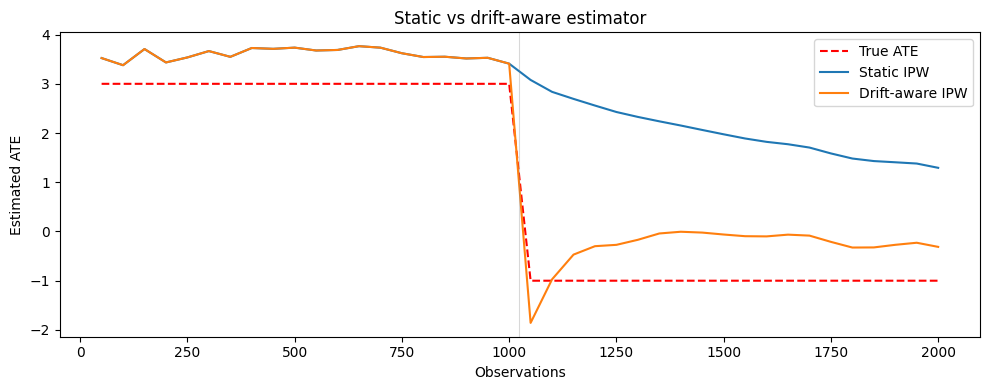

In [3]:
LOG_EVERY = 50

# Static: never resets
static_ipw  = OnlineIPW()
static_ates = []

# Drift-aware: resets when ADWIN detects drift
aware_ipw   = OnlineIPW()
aware_ates  = []
monitor     = ConceptDriftMonitor(delta=0.002)
detected_at = []

for i, (x, w, y, tau) in enumerate(
    DriftingCausalStream(n=2000, true_ate=3.0, shifted_ate=-1.0,
                         changepoint=1000, seed=42)
):
    # Static
    static_ipw.learn_one(x, w, y)

    # Drift-aware
    ps = max(0.01, min(0.99, aware_ipw.ps_model.predict_one(x)))
    psi = (w * y / ps) - ((1 - w) * y / (1 - ps))
    monitor.update(psi)
    if monitor.drift_detected:
        aware_ipw.reset()
        detected_at.append(i)
    aware_ipw.learn_one(x, w, y)

    if (i + 1) % LOG_EVERY == 0:
        static_ates.append(static_ipw.predict_ate())
        aware_ates.append(aware_ipw.predict_ate())

steps = [(i + 1) * LOG_EVERY for i in range(len(static_ates))]
true_ate_curve = [3.0 if s <= 1000 else -1.0 for s in steps]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, true_ate_curve, color="red", linestyle="--", label="True ATE")
ax.plot(steps, static_ates, label="Static IPW", color="tab:blue")
ax.plot(steps, aware_ates, label="Drift-aware IPW", color="tab:orange")
for d in detected_at:
    ax.axvline(d, color="gray", alpha=0.3, linewidth=0.8)
ax.set_xlabel("Observations")
ax.set_ylabel("Estimated ATE")
ax.set_title("Static vs drift-aware estimator")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/concept_drift.png", dpi=100)
print(f"Drifts detected: {monitor.n_drifts} at steps: {detected_at[:5]}")

## 3. Effect of ADWIN delta on sensitivity

In [4]:
for delta in [0.1, 0.01, 0.002, 0.0002]:
    mon = ConceptDriftMonitor(delta=delta)
    ipw = OnlineIPW()
    for x, w, y, _ in DriftingCausalStream(n=2000, true_ate=3.0, shifted_ate=-1.0,
                                             changepoint=1000, seed=0):
        ps = max(0.01, min(0.99, ipw.ps_model.predict_one(x)))
        psi = (w * y / ps) - ((1 - w) * y / (1 - ps))
        mon.update(psi)
        ipw.learn_one(x, w, y)
    print(f"delta={delta:.4f}  n_drifts={mon.n_drifts}")

delta=0.1000  n_drifts=1
delta=0.0100  n_drifts=1
delta=0.0020  n_drifts=1
delta=0.0002  n_drifts=1
